In [1]:

import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


plt.tight_layout()
import warnings
warnings.filterwarnings('ignore')

<Figure size 640x480 with 0 Axes>

In [2]:
df = pd.read_csv('home equity.csv')
print(df.head(100).to_string())

    BAD  LOAN   MORTDUE     VALUE   REASON      JOB   YOJ  DEROG  DELINQ       CLAGE  NINQ  CLNO    DEBTINC
0     1  1100   25860.0   39025.0  HomeImp    Other  10.5    0.0     0.0   94.366667   1.0   9.0        NaN
1     1  1300   70053.0   68400.0  HomeImp    Other   7.0    0.0     2.0  121.833333   0.0  14.0        NaN
2     1  1500   13500.0   16700.0  HomeImp    Other   4.0    0.0     0.0  149.466667   1.0  10.0        NaN
3     1  1500       NaN       NaN      NaN      NaN   NaN    NaN     NaN         NaN   NaN   NaN        NaN
4     0  1700   97800.0  112000.0  HomeImp   Office   3.0    0.0     0.0   93.333333   0.0  14.0        NaN
5     1  1700   30548.0   40320.0  HomeImp    Other   9.0    0.0     0.0  101.466002   1.0   8.0  37.113614
6     1  1800   48649.0   57037.0  HomeImp    Other   5.0    3.0     2.0   77.100000   1.0  17.0        NaN
7     1  1800   28502.0   43034.0  HomeImp    Other  11.0    0.0     0.0   88.766030   0.0   8.0  36.884894
8     1  2000   32700.0   46

In [3]:
df.info()
print('____________________________________\n')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB
____________________________________



BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64

In [4]:
df.describe()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['JOB']=df['JOB'].fillna('Other')
df.isnull().sum()

BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB           0
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64

In [7]:
df['REASON']=df['REASON'].fillna('Unkown')
df.head(30)

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,Unkown,Other,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN
5,1,1700,30548.0,40320.0,HomeImp,Other,9.0,0.0,0.0,101.466002,1.0,8.0,37.113614
6,1,1800,48649.0,57037.0,HomeImp,Other,5.0,3.0,2.0,77.100000,1.0,17.0,NaN
7,1,1800,28502.0,43034.0,HomeImp,Other,11.0,0.0,0.0,88.766030,0.0,8.0,36.884894
8,1,2000,32700.0,46740.0,HomeImp,Other,3.0,0.0,2.0,216.933333,1.0,12.0,NaN
9,1,2000,NaN,62250.0,HomeImp,Sales,16.0,0.0,0.0,115.800000,0.0,13.0,NaN


In [8]:
df['MORTDUE']=df['MORTDUE'].fillna(df['MORTDUE'].median())
df['VALUE']=df['VALUE'].fillna(df['VALUE'].median())
df['YOJ']=df['YOJ'].fillna(df['YOJ'].median())
df['CLAGE']=df['CLAGE'].fillna(df['CLAGE'].median())
df['CLNO']=df['CLNO'].fillna(df['CLNO'].median())
df['DEROG']=df['DEROG'].fillna(0)
df['DELINQ']=df['DELINQ'].fillna(0)
df['NINQ']=df['NINQ'].fillna(0)
df['DEBTINC']=df['DEBTINC'].fillna(df['DEBTINC'].median())
df.isnull().sum()

BAD        0
LOAN       0
MORTDUE    0
VALUE      0
REASON     0
JOB        0
YOJ        0
DEROG      0
DELINQ     0
CLAGE      0
NINQ       0
CLNO       0
DEBTINC    0
dtype: int64

In [9]:
Q1_mort= df.MORTDUE.quantile(0.25)
Q3_mort = df.MORTDUE.quantile(0.75)
IQR_mort = Q3_mort- Q1_mort
lower_mort = Q1_mort - 1.5*IQR_mort
upper_mort = Q3_mort + 1.5*IQR_mort
df['MORTDUE']=np.where(df['MORTDUE']>upper_mort,upper_mort,
np.where(df['MORTDUE']<lower_mort,lower_mort,df['MORTDUE']))

In [10]:
Q1_val= df.VALUE.quantile(0.25)
Q3_val = df.VALUE.quantile(0.75)
IQR_val = Q3_val- Q1_val
lower_val = Q1_val - 1.5*IQR_val
upper_val = Q3_val + 1.5*IQR_val
df['VALUE']=np.where(df['VALUE']>upper_val,upper_val,
np.where(df['VALUE']<lower_val,lower_val,df['VALUE']))

In [11]:
Q1_yoj= df.YOJ.quantile(0.25)
Q3_yoj = df.YOJ.quantile(0.75)
IQR_yoj = Q3_yoj- Q1_yoj
lower_yoj = Q1_yoj - 1.5*IQR_yoj
upper_yoj = Q3_yoj + 1.5*IQR_yoj
df['YOJ']=np.where(df['YOJ']>upper_yoj,upper_yoj,
np.where(df['YOJ']<lower_yoj,lower_yoj,df['YOJ']))

In [12]:
Q1_clg= df.CLAGE.quantile(0.25)
Q3_clg = df.CLAGE.quantile(0.75)
IQR_clg = Q3_clg- Q1_clg
lower_clg = Q1_clg - 1.5*IQR_clg
upper__clg = Q3_clg + 1.5*IQR_clg
df['CLAGE']=np.where(df['CLAGE']>upper__clg,upper__clg,
np.where(df['CLAGE']<lower_clg,lower_clg,df['CLAGE']))

In [13]:
Q1_clno= df.CLNO.quantile(0.25)
Q3_clno = df.CLNO.quantile(0.75)
IQR_clno = Q3_clno- Q1_clno
lower_clno = Q1_clno - 1.5*IQR_clno
upper_clno = Q3_clno + 1.5*IQR_clno
df['CLNO']=np.where(df['CLNO']>upper_clno,upper_clno,
np.where(df['CLNO']<lower_clno,lower_clno,df['CLNO']))

In [14]:
Q1_dbt= df.DEBTINC.quantile(0.25)
Q3_dbt = df.DEBTINC.quantile(0.75)
IQR_dbt = Q3_dbt - Q1_dbt
lower_dbt = Q1_dbt - 1.5*IQR_dbt
upper_dbt = Q3_dbt+ 1.5*IQR_dbt
df['DEBTINC']=np.where(df['DEBTINC']>upper_dbt,upper_dbt,
np.where(df['DEBTINC']<lower_dbt,lower_dbt,df['DEBTINC']))

In [15]:
df= pd.get_dummies(df,columns = ['JOB','REASON'])
df.head()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,JOB_Mgr,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self,REASON_DebtCon,REASON_HomeImp,REASON_Unkown
0,1,1100,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,34.818262,False,False,True,False,False,False,False,True,False
1,1,1300,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,34.818262,False,False,True,False,False,False,False,True,False
2,1,1500,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,34.818262,False,False,True,False,False,False,False,True,False
3,1,1500,65019.0,89235.5,7.0,0.0,0.0,173.466667,0.0,20.0,34.818262,False,False,True,False,False,False,False,False,True
4,0,1700,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,34.818262,False,True,False,False,False,False,False,True,False


In [16]:
numeric_cols= ['LOAN','MORTDUE','VALUE','YOJ','DEROG','DELINQ','CLAGE','NINQ','CLNO','DEBTINC']
df[numeric_cols]=scaler.fit_transform(df[numeric_cols])

In [17]:
pca = PCA(n_components=0.8)
pca_features=pca.fit_transform(df)

In [18]:
pca_cols=['PCA1','PCA2','PCA3','PCA4','PCA5','PCA6','PCA7','PCA8']
df_pca=pd.DataFrame(data=pca_features,columns=pca_cols)
df_pca.head(30)

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8
0,-2.807868,0.098872,-0.395742,-0.188723,0.683436,0.525569,0.471012,0.940703
1,-1.359521,0.467441,0.203916,-1.591752,0.351816,1.507528,0.416430,0.251910
2,-3.113120,0.185900,-0.385392,-0.491270,0.998294,-0.058994,-0.228381,0.200569
3,-0.820091,-0.305465,-0.306387,-1.104840,0.780897,0.036457,-0.003952,0.686625
4,-0.384223,-0.179506,-1.636110,-1.518737,0.224734,0.620552,0.381430,0.909709
5,-2.651955,0.243322,-0.580116,-0.163191,0.858728,0.623749,0.214901,0.947848
6,-1.947511,2.927128,0.848263,-1.706718,-1.472058,0.191183,-0.706913,1.619265
7,-2.714438,-0.110518,-0.479240,-0.267106,0.707445,0.980657,0.061683,1.186699
8,-2.025467,0.565010,0.708404,-1.312568,0.826887,0.585848,-0.143287,-0.557135
9,-1.503424,-0.538472,-0.058292,-0.478320,0.496257,0.821011,0.636457,1.556633


In [19]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.20441092 0.12710543 0.10936244 0.09163424 0.08536461 0.07206481
 0.06914165 0.06533267]
0.8244167764084396


## Visual Storyteller
This section presents key visual insights from the dataset.


Plot 1: Distribution of Loan Amount


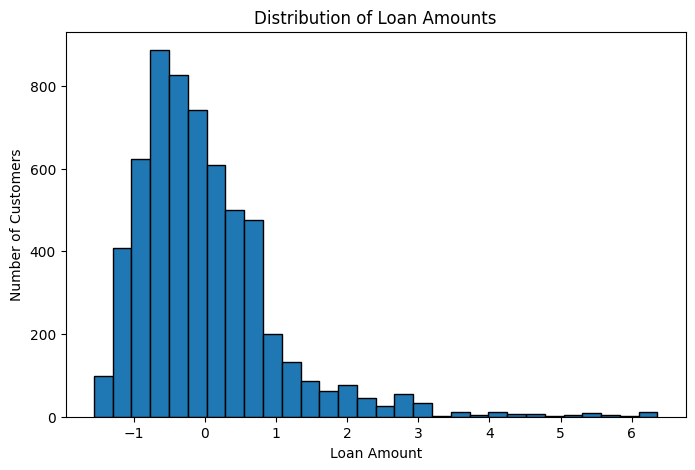

In [20]:
plt.figure(figsize=(8,5))
plt.hist(df['LOAN'], bins=30, edgecolor='black')
plt.title('Distribution of Loan Amounts')
plt.xlabel('Loan Amount')
plt.ylabel('Number of Customers')
plt.show()

Explanation: Most customers take small loans, while only a few take large loans.


Plot 2: Good vs Bad Customers (Pie Chart)


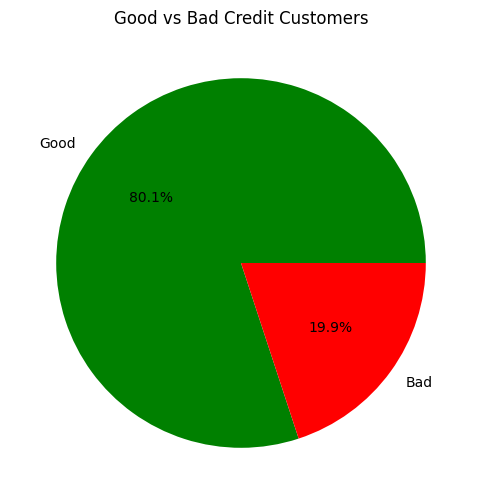

In [21]:
plt.figure(figsize=(6,6))
df['BAD'].value_counts().plot.pie(autopct='%1.1f%%', labels=['Good', 'Bad'], colors=['green','red'])
plt.title('Good vs Bad Credit Customers')
plt.ylabel('')
plt.show()

Explanation: About 80% of customers have good credit, and 20% have bad credit.


Plot 3: Property Value vs Loan Amount


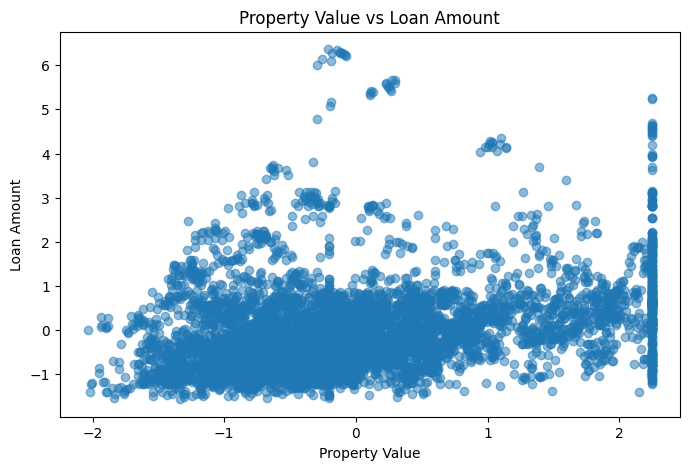

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(df['VALUE'], df['LOAN'], alpha=0.5)
plt.xlabel('Property Value')
plt.ylabel('Loan Amount')
plt.title('Property Value vs Loan Amount')
plt.show()

Explanation: There is a positive relationship - higher property values are


Plot 4: Distribution of Years on Job


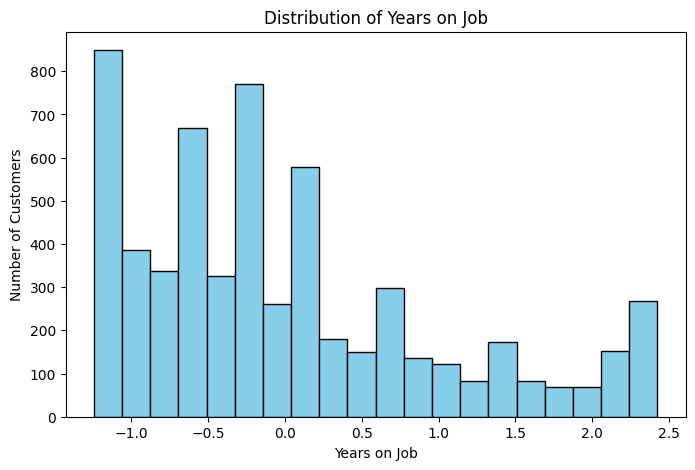

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df['YOJ'], bins=20, edgecolor='black', color='skyblue')
plt.title('Distribution of Years on Job')
plt.xlabel('Years on Job')
plt.ylabel('Number of Customers')
plt.show()

Explanation: Most customers have between 0 and 15 years of job experience, with few having more than 20 years.



Plot 5: Average Debt-to-Income by Credit Status


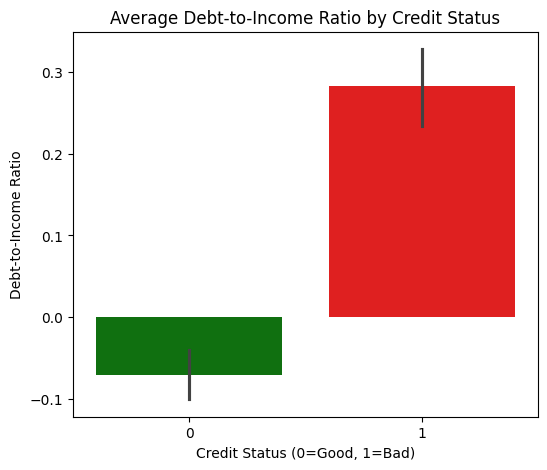

In [24]:
plt.figure(figsize=(6,5))
sns.barplot(x='BAD', y='DEBTINC', data=df, palette=['green','red'])
plt.title('Average Debt-to-Income Ratio by Credit Status')
plt.xlabel('Credit Status (0=Good, 1=Bad)')
plt.ylabel('Debt-to-Income Ratio')
plt.show()

Explanation: Customers with bad credit have a higher debt-to-income ratio compared to customers with good credit.


# K-Medoid Cluster

In [25]:
from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import StandardScaler

In [26]:
k=3
Kmedoids_model = KMedoids(n_clusters=k, metric="manhattan",init="random")
X = df[numeric_cols].dropna()
scaler = StandardScaler()
X_scaled =scaler.fit_transform(X)


In [27]:
Kmedoids_model.fit(X_scaled)

,n_clusters,3
,metric,'manhattan'
,method,'alternate'
,init,'random'
,max_iter,300
,random_state,None


In [28]:
labels= Kmedoids_model.labels_
labels

array([0, 0, 0, ..., 0, 0, 0], shape=(5960,))

In [29]:
centers=Kmedoids_model.cluster_centers_
print("centers", centers)

centers [[-0.51826609 -0.54314582 -0.68172446 -0.38044442 -0.28097618 -0.37594296
  -0.06103342 -0.64332357 -0.10756564  0.13745593]
 [-0.19702511 -0.22435007 -0.43004179 -0.23661503 -0.28097618 -0.37594296
  -0.06103342 -0.64332357 -0.10756564 -1.53885452]
 [ 0.16883268  0.3517225   0.26405995 -0.23661503 -0.28097618 -0.37594296
  -0.02384873 -0.05016013  0.4333027   0.64921403]]


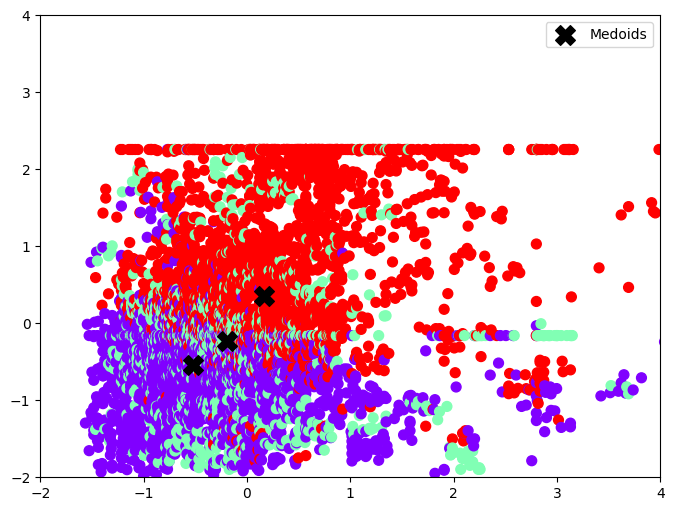

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=Kmedoids_model.labels_, cmap='rainbow', s=50)
plt.scatter(X_scaled[Kmedoids_model.medoid_indices_, 0],
            X_scaled[Kmedoids_model.medoid_indices_, 1],
            c='black', s=200, marker='X', label='Medoids')
plt.xlim(-2, 4)
plt.ylim(-2, 4)
plt.legend()
plt.show()

In [31]:
medoid_indices = Kmedoids_model.medoid_indices_
print(" Medoids_indices:", medoid_indices)

medoids_original = df.iloc[medoid_indices]
print(medoids_original)

 Medoids_indices: [1966 2983 3904]
      BAD      LOAN   MORTDUE     VALUE       YOJ     DEROG    DELINQ  \
1966    1 -0.518266 -0.543146 -0.681724 -0.380444 -0.280976 -0.375943   
2983    0 -0.197025 -0.224350 -0.430042 -0.236615 -0.280976 -0.375943   
3904    0  0.168833  0.351722  0.264060 -0.236615 -0.280976 -0.375943   

         CLAGE      NINQ      CLNO   DEBTINC  JOB_Mgr  JOB_Office  JOB_Other  \
1966 -0.061033 -0.643324 -0.107566  0.137456    False       False      False   
2983 -0.061033 -0.643324 -0.107566 -1.538855    False       False       True   
3904 -0.023849 -0.050160  0.433303  0.649214    False       False       True   

      JOB_ProfExe  JOB_Sales  JOB_Self  REASON_DebtCon  REASON_HomeImp  \
1966         True      False     False           False            True   
2983        False      False     False            True           False   
3904        False      False     False            True           False   

      REASON_Unkown  
1966          False  
2983      

## Key Findings:
### Medoid C (Row 2260) is the only one with BAD = 1 (actual default)
    Highest DELINQ = 3
    Missing DEBTINC (possible red flag)
    → High risk

### Medoid B (Row 802) has BAD = 0 but:

    High DEBTINC (37.98%, close to danger zone 40%)

    High NINQ = 3 (seeking new credit)

    → Medium risk
    
### Medoid A (Row 2920) is the safest:
    Low DEBTINC (34.21%)

    Professional executive job (ProfExe)

    NINQ = 0 (no new credit lines)

    → Low risk

## Hierarchical Clustering (Ward)


In [32]:
X = df.select_dtypes(include=[np.number]).drop(columns=['BAD'])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

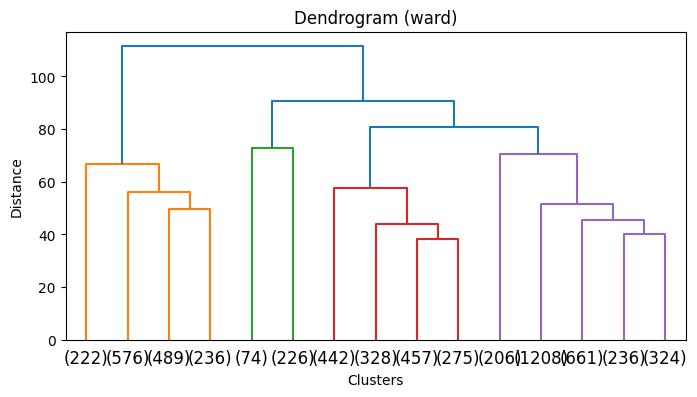

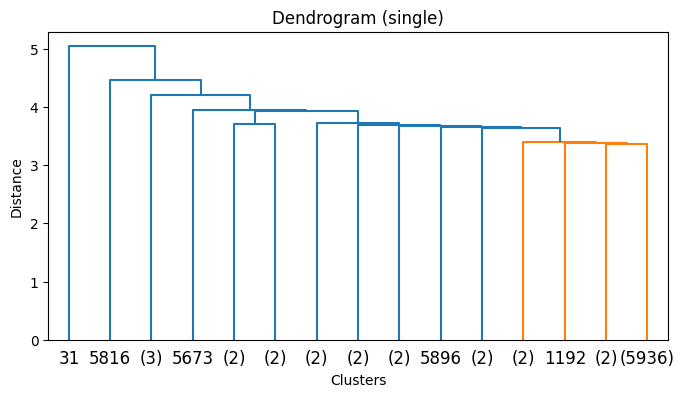

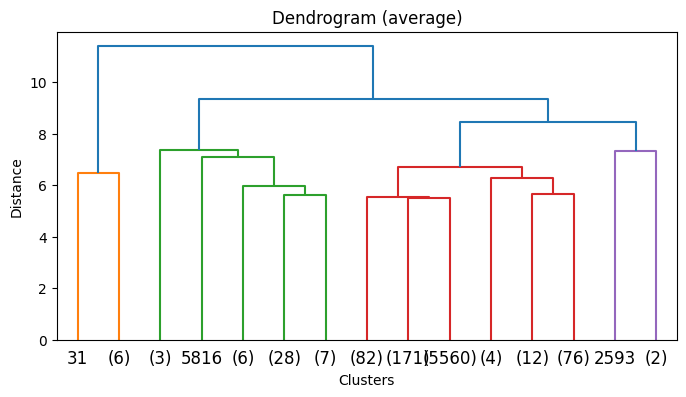

In [33]:
methods = ['ward', 'single', 'average']

for method in methods:
    plt.figure(figsize=(8, 4))
    sch.dendrogram(sch.linkage(X_scaled, method=method), truncate_mode='lastp', p=15)
    plt.title(f'Dendrogram ({method})')
    plt.xlabel('Clusters')
    plt.ylabel('Distance')
    plt.show()

In [34]:
from sklearn.metrics import silhouette_score

results = []

for method in methods:
    for k in range(2, 6):
        model = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = model.fit_predict(X_scaled)

        score = silhouette_score(X_scaled, labels)
        results.append((method, k, score))

results_df = pd.DataFrame(results, columns=['method', 'k', 'silhouette'])
print(results_df.sort_values(by='silhouette', ascending=False))

     method  k  silhouette
4    single  2    0.710084
8   average  2    0.629933
5    single  3    0.618539
6    single  4    0.614896
7    single  5    0.612942
9   average  3    0.553766
10  average  4    0.499371
11  average  5    0.497346
1      ward  3    0.166940
0      ward  2    0.148690
3      ward  5    0.093708
2      ward  4    0.085425


### Best method: Single linkage (k=2)

* Single linkage achieved the highest silhouette score (0.71),
* but its missleading

In [35]:
# PCA for visualization
pca_vis = PCA(n_components=2)
X_vis   = pca_vis.fit_transform(X_scaled)

# We can't plot 20 features directly, so PCA compresses them into 2 axes.

agglo_cluster
0    5959
1       1
Name: count, dtype: int64


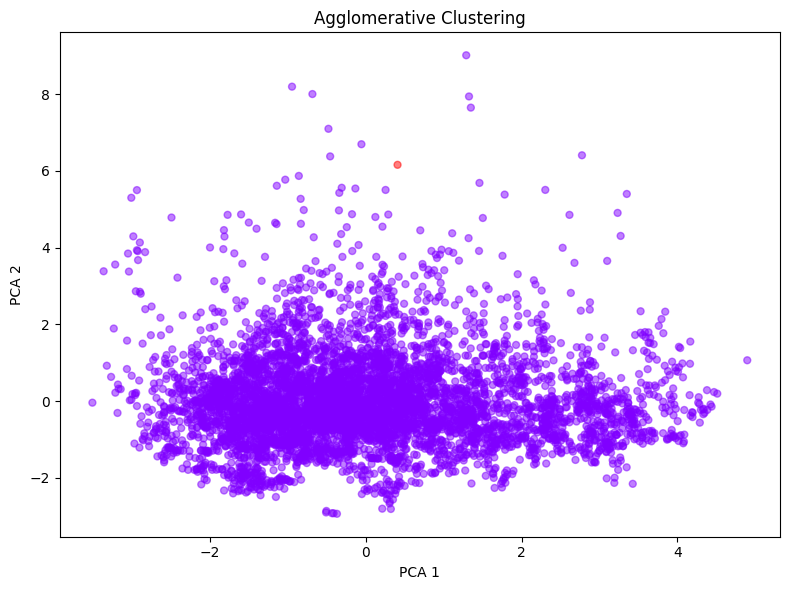

In [36]:
# we use single and k=2

final_model = AgglomerativeClustering(n_clusters=2 , linkage='single')

df['agglo_cluster'] = final_model.fit_predict(X_scaled)

print(df['agglo_cluster'].value_counts())


plt.figure(figsize=(8, 6))
plt.scatter(X_vis[:, 0], X_vis[:, 1],
            c=df['agglo_cluster'], s=25,cmap='rainbow', alpha=0.5)
plt.title('Agglomerative Clustering')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.tight_layout()
plt.show()



agglo_cluster
0    5908
2      45
1       7
Name: count, dtype: int64


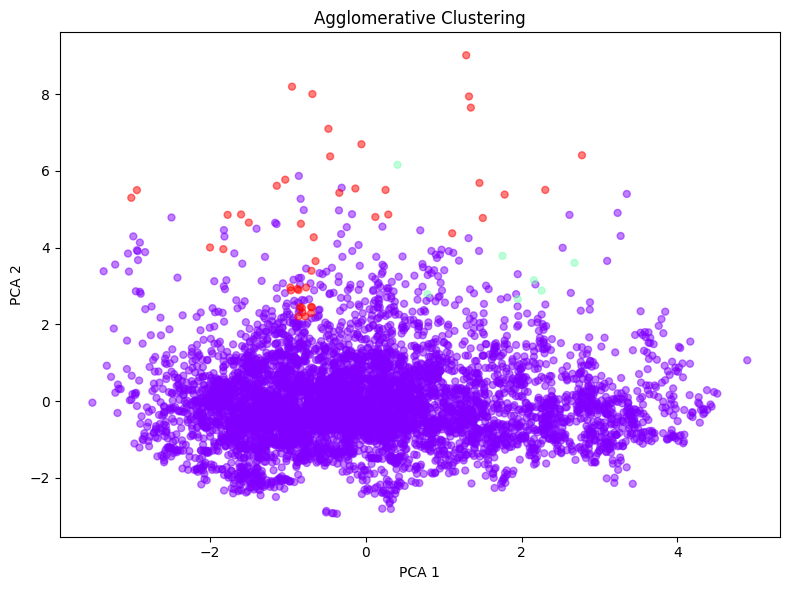

In [37]:
# we use average and k=3

final_model = AgglomerativeClustering(n_clusters=3 , linkage='average')

df['agglo_cluster'] = final_model.fit_predict(X_scaled)

print(df['agglo_cluster'].value_counts())

plt.figure(figsize=(8, 6))
plt.scatter(X_vis[:, 0], X_vis[:, 1],
            c=df['agglo_cluster'], s=25,cmap='rainbow', alpha=0.5)
plt.title('Agglomerative Clustering')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.tight_layout()
plt.show()

agglo_cluster
0    4137
1    1523
2     300
Name: count, dtype: int64


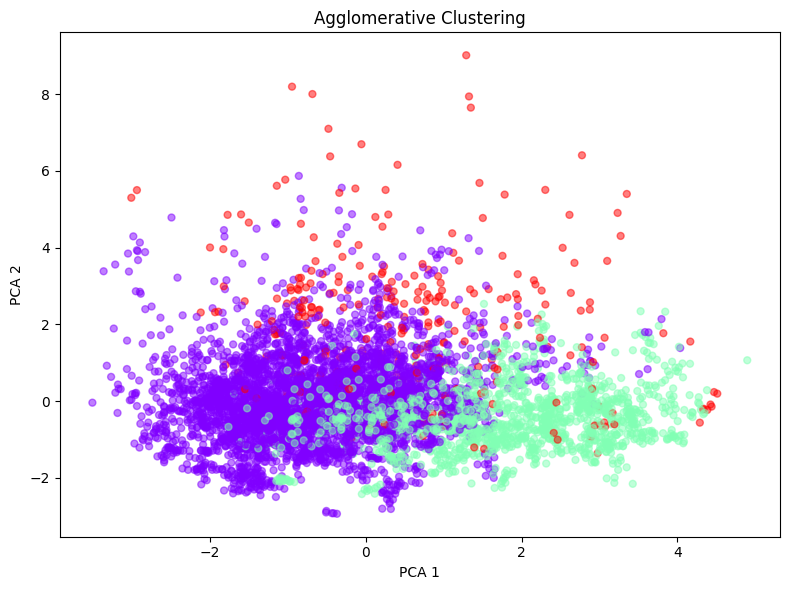

In [38]:
# we use ward and k=3

final_model = AgglomerativeClustering(n_clusters=3 , linkage='ward')

df['agglo_cluster'] = final_model.fit_predict(X_scaled)

print(df['agglo_cluster'].value_counts())

plt.figure(figsize=(8, 6))
plt.scatter(X_vis[:, 0], X_vis[:, 1],
            c=df['agglo_cluster'], s=25,cmap='rainbow', alpha=0.5)
plt.title('Agglomerative Clustering')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.tight_layout()
plt.show()


In [39]:
#  Cluster profiling 
profile = df.groupby('agglo_cluster')[numeric_cols].mean().round(3)
print(profile)


                LOAN  MORTDUE  VALUE    YOJ  DEROG  DELINQ  CLAGE   NINQ  \
agglo_cluster                                                              
0             -0.273   -0.343 -0.376 -0.151 -0.079  -0.119 -0.150  0.011   
1              0.741    0.919  1.008  0.356 -0.197  -0.223  0.365 -0.058   
2             -0.002    0.066  0.071  0.273  2.086   2.778  0.213  0.140   

                CLNO  DEBTINC  
agglo_cluster                  
0             -0.224   -0.080  
1              0.477    0.212  
2              0.675    0.020  


## Cluster profiling (Ward, k=3)

### Cluster 0:
### - Higher LOAN, MORTDUE, VALUE → wealthier customers
### - More CLNO → more active credit lines
### - Slightly higher DEROG & DELINQ → moderate risk
###
### Cluster 1:
### - Lower LOAN, MORTDUE, VALUE → smaller financial scale
### - Fewer CLNO → less credit activity
### - Lower DEROG & DELINQ → lower risk segment
###
### Cluster 2:
### - Extremely high DEROG → severe credit issues
### - Higher DELINQ, NINQ, DEBTINC → strong financial stress
### - Lower CLAGE → weak/short credit history
### - Higher CLNO → possibly overextended credit

## fuzzy logic

In [40]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [41]:
# define antecedents (inputs)
cluster_id = ctrl.Antecedent(np.arange(0, 3, 1), 'cluster_id')
debtinc = ctrl.Antecedent(np.arange(0, 101, 1), 'debtinc')

In [42]:
# define consequents (outputs)
loan_acceptance = ctrl.Consequent(np.arange(0, 101, 1), 'loan_acceptance')

In [43]:
# define fuzzy membership functions
cluster_id['safe'] = fuzz.trimf(cluster_id.universe, [0, 0, 1])
cluster_id['average'] = fuzz.trimf(cluster_id.universe, [0, 1, 2])
cluster_id['risky'] = fuzz.trimf(cluster_id.universe, [1, 2, 2])

debtinc['low'] = fuzz.trapmf(debtinc.universe, [0, 0, 20, 40])
debtinc['medium'] = fuzz.trimf(debtinc.universe, [30, 50, 70])
debtinc['high'] = fuzz.trapmf(debtinc.universe, [60, 80, 100, 100])

loan_acceptance['low'] = fuzz.trapmf(loan_acceptance.universe, [0, 0, 20, 40])
loan_acceptance['medium'] = fuzz.trimf(loan_acceptance.universe, [30, 50, 70])
loan_acceptance['high'] = fuzz.trapmf(loan_acceptance.universe, [60, 80, 100, 100])

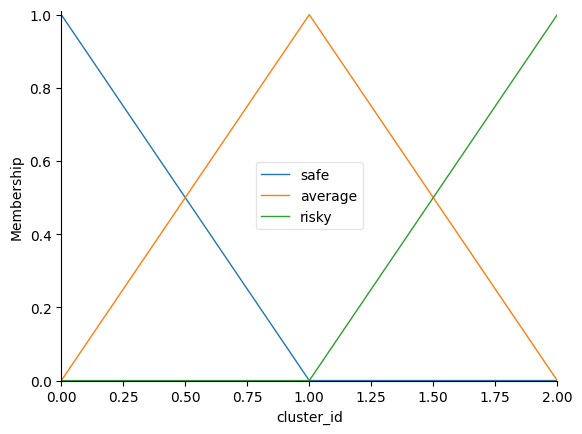

In [44]:
import warnings
warnings.filterwarnings('ignore')
cluster_id.view()

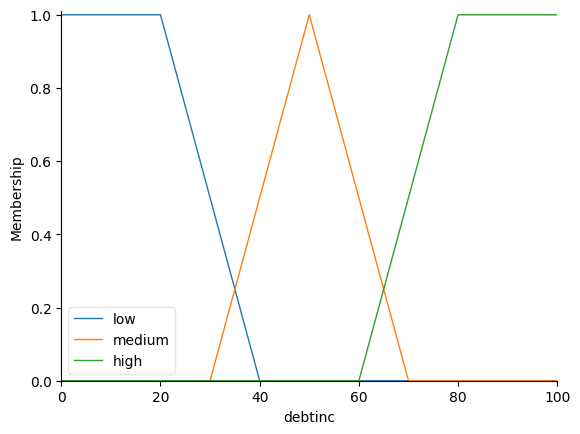

In [45]:
debtinc.view()

In [46]:
 # define fuzzy rules
#Rule 1: IF Safe Cluster AND Low Debt THEN High Acceptance
rule1 = ctrl.Rule(cluster_id['safe'] & debtinc['low'], loan_acceptance['high'])

#Rule 2: IF Safe Cluster AND Medium Debt THEN High Acceptance
rule2 = ctrl.Rule(cluster_id['safe'] & debtinc['medium'], loan_acceptance['high'])

#Rule 3: IF Safe Cluster AND High Debt THEN Medium Acceptance
rule3 = ctrl.Rule(cluster_id['safe'] & debtinc['high'], loan_acceptance['medium'])

#Rule 4: IF Average Cluster AND Low Debt THEN High Acceptance
rule4 = ctrl.Rule(cluster_id['average'] & debtinc['low'], loan_acceptance['high'])

# Rule 5: IF Average Cluster AND Medium Debt THEN Medium Acceptance
rule5 = ctrl.Rule(cluster_id['average'] & debtinc['medium'], loan_acceptance['medium'])

# Rule 6: IF Average Cluster AND High Debt THEN Low Acceptance
rule6 = ctrl.Rule(cluster_id['average'] & debtinc['high'], loan_acceptance['low'])

# Rule 7: IF Risky Cluster AND Low Debt THEN Medium Acceptance
rule7 = ctrl.Rule(cluster_id['risky'] & debtinc['low'], loan_acceptance['medium'])

# Rule 8: IF Risky Cluster AND Medium Debt THEN Low Acceptance
rule8 = ctrl.Rule(cluster_id['risky'] & debtinc['medium'], loan_acceptance['low'])

# Rule 9: IF Risky Cluster AND High Debt THEN Low Acceptance
rule9 = ctrl.Rule(cluster_id['risky'] & debtinc['high'], loan_acceptance['low'])

In [47]:
# create fuzzy control system
loan_system = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])

In [48]:
# create fuzzy simulator
loan_simulator = ctrl.ControlSystemSimulation(loan_system)

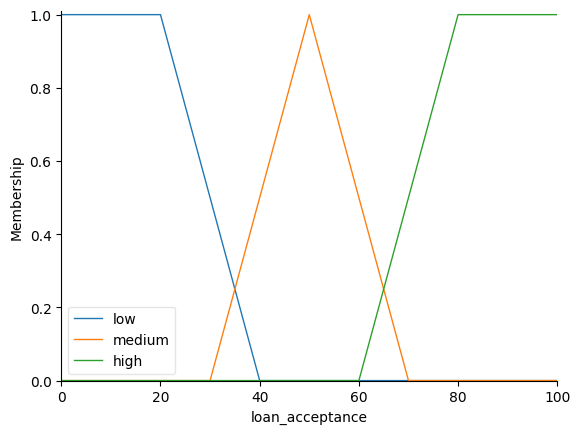

In [49]:
loan_acceptance.view(sim= loan_simulator)

In [50]:
# set inputs value
index = np.random.randint(0, len(df['DEBTINC']))
loan_simulator.input['cluster_id'] = df['agglo_cluster'].iloc[index]
loan_simulator.input['debtinc'] = df['DEBTINC'].iloc[index]

In [51]:
# Run simulator
loan_simulator.compute()

In [52]:
# get output value
loan_acceptance_value = loan_simulator.output['loan_acceptance']

In [53]:
# Print output value
print(f"The loan acceptance probability is {round(loan_acceptance_value, 1)}%")

The loan acceptance probability is 84.4%


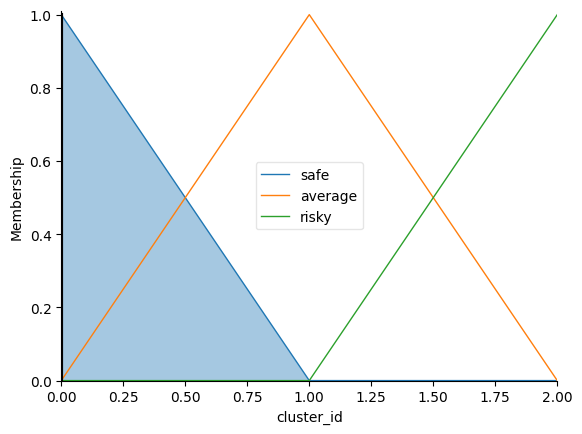

In [54]:
cluster_id.view(sim=loan_simulator)


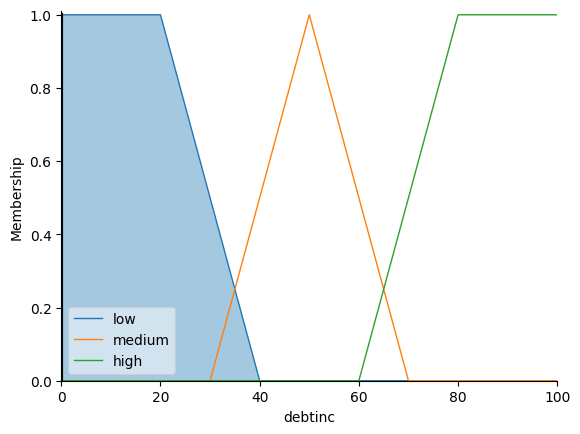

In [55]:
debtinc.view(sim=loan_simulator)


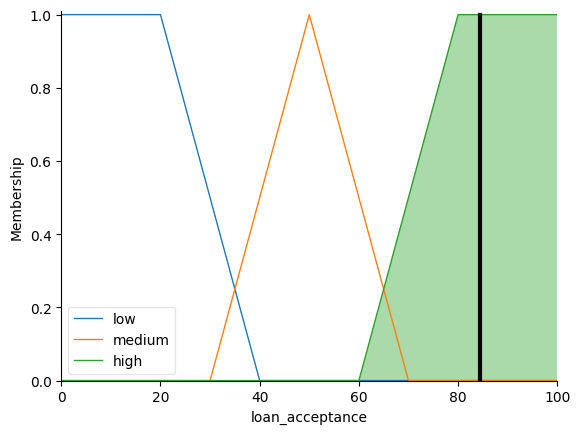

In [56]:
loan_acceptance.view(sim=loan_simulator)

Customer Index: 0
Cluster ID: 0
Debt Ratio: 0.14
------------------------------
Loan Acceptance Probability: 84.44%


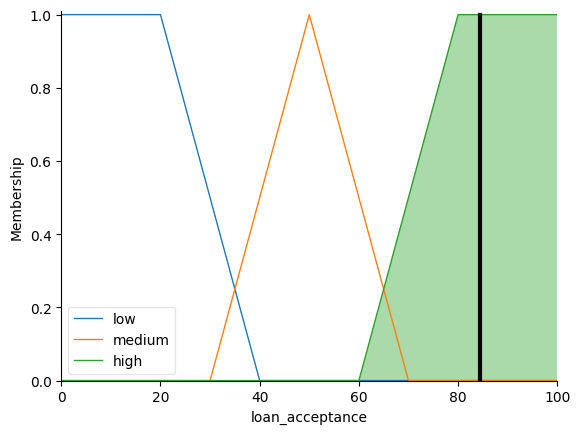

In [57]:
index = 0

loan_simulator.input['cluster_id'] = df['agglo_cluster'].iloc[index]
loan_simulator.input['debtinc'] = df['DEBTINC'].iloc[index]

loan_simulator.compute()

print(f"Customer Index: {index}")
print(f"Cluster ID: {df['agglo_cluster'].iloc[index]}")
print(f"Debt Ratio: {df['DEBTINC'].iloc[index]:.2f}")
print("-" * 30)
print(f"Loan Acceptance Probability: {loan_simulator.output['loan_acceptance']:.2f}%")

loan_acceptance.view(sim=loan_simulator)

## Genetic_Algorithm

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import random

In [59]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("string colums", list(categorical_cols))

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

X = df.drop('BAD', axis=1)
y = df['BAD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


POPULATION_SIZE = 10
MUTATION_PROB = 0.1
GENERATIONS = 20
N_FEATURES = X.shape[1]

print(f"nomber of featres {N_FEATURES}")

def fitness(chromosome):
    selected_features = [i for i in range(N_FEATURES) if chromosome[i] == 1]

    if len(selected_features) == 0:
        return 0.0

    X_train_sel = X_train.iloc[:, selected_features]
    X_test_sel = X_test.iloc[:, selected_features]

    try:
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train_sel, y_train)
        y_pred = model.predict(X_test_sel)
        return accuracy_score(y_test, y_pred)
    except:
        return 0.0

def create_individual():
    return [random.randint(0, 1) for _ in range(N_FEATURES)]

def select_parent(population):
    tournament = random.sample(population, min(3, len(population)))
    return max(tournament, key=lambda chrom: fitness(chrom))

def crossover(parent1, parent2):
    point = random.randint(1, N_FEATURES - 1)
    return parent1[:point] + parent2[point:]

def mutate(individual):
    for i in range(len(individual)):
        if random.random() < MUTATION_PROB:
            individual[i] = 1 - individual[i]
    return individual

def genetic_algorithm():
    population = [create_individual() for _ in range(POPULATION_SIZE)]
    best_fitness_history = []

    for gen in range(GENERATIONS):

        fitness_scores = [fitness(chrom) for chrom in population]
        population = [chrom for _, chrom in sorted(zip(fitness_scores, population), reverse=True)]
        current_best = fitness(population[0])
        best_fitness_history.append(current_best)
        print(f"Generation {gen+1}: Best Fitness = {current_best:.4f}")


        new_population = []
        for _ in range(POPULATION_SIZE):
            p1 = select_parent(population)
            p2 = select_parent(population)
            child = crossover(p1, p2)
            child = mutate(child)
            new_population.append(child)
        population = new_population


    final_fitness_scores = [fitness(chrom) for chrom in population]
    best_index = final_fitness_scores.index(max(final_fitness_scores))
    best = population[best_index]
    selected = [i for i in range(N_FEATURES) if best[i] == 1]

    print("final result")
    print(f"best acurecy {max(final_fitness_scores):.4f}")
    print(f"nom of features {len(selected)}")
    print(f"selected features {selected}")
    print(f" selected features {list(X.columns[selected])}")



genetic_algorithm()

string colums []
nomber of featres 20
Generation 1: Best Fitness = 0.8154
Generation 2: Best Fitness = 0.8221
Generation 3: Best Fitness = 0.8230
Generation 4: Best Fitness = 0.8213
Generation 5: Best Fitness = 0.8213
Generation 6: Best Fitness = 0.8230
Generation 7: Best Fitness = 0.8221
Generation 8: Best Fitness = 0.8238
Generation 9: Best Fitness = 0.8238
Generation 10: Best Fitness = 0.8230
Generation 11: Best Fitness = 0.8230
Generation 12: Best Fitness = 0.8230
Generation 13: Best Fitness = 0.8213
Generation 14: Best Fitness = 0.8221
Generation 15: Best Fitness = 0.8238
Generation 16: Best Fitness = 0.8188
Generation 17: Best Fitness = 0.8205
Generation 18: Best Fitness = 0.8230
Generation 19: Best Fitness = 0.8221
Generation 20: Best Fitness = 0.8221
final result
best acurecy 0.8196
nom of features 15
selected features [0, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 18, 19]
 selected features ['LOAN', 'VALUE', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'JOB_Mgr', 'JOB_

#system implementation

In [60]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def integration_pipeline(df):

    print("Step 1: Preprocessing...")

    df['JOB'] = df['JOB'].fillna('Other')
    df['REASON'] = df['REASON'].fillna('Unknown')

    cols = ['MORTDUE','VALUE','YOJ','CLAGE','CLNO','DEBTINC']
    for c in cols:
        df[c] = df[c].fillna(df[c].median())

    for c in ['DEROG','DELINQ','NINQ']:
        df[c] = df[c].fillna(0)

    df = pd.get_dummies(df, columns=['JOB','REASON'])

    print("Step 2: Scaling...")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('BAD')

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[numeric_cols])

    print("Step 3: PCA...")

    pca = PCA(n_components=0.8)
    X_pca = pca.fit_transform(X_scaled)

    print("Integration Done ✔")

    return X_scaled, X_pca, df


df = pd.read_csv("home equity.csv")

X_scaled, X_pca, df_clean = integration_pipeline(df)

print("Scaled shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Step 1: Preprocessing...
Step 2: Scaling...
Step 3: PCA...
Integration Done ✔
Scaled shape: (5960, 10)
PCA shape: (5960, 7)
